In [2]:
import os
from dotenv import load_dotenv

from typing import TypedDict

from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq
from langchain.tools import tool

from  langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

True

In [7]:
llm = ChatGroq(api_key=os.environ["GROQ_API_KEY"], model='openai/gpt-oss-120b')

@tool
def search_movie_api():
    """Invokes movie API according to user requirements"""
    return "Karuppu"

tools = [search_movie_api]

llm_with_tools = llm.bind_tools(tools=tools)

class AgentState(TypedDict):
    messages: str

def llm_node(state: AgentState):
    response = llm_with_tools.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [13]:
graph = StateGraph(AgentState)
graph.add_node("llm_node", llm_node)
graph.add_node("tools", ToolNode(tools))

graph.add_conditional_edges("llm_node", tools_condition)
graph.add_edge(START, "llm_node")
graph.add_edge("tools", END)
agent = graph.compile()

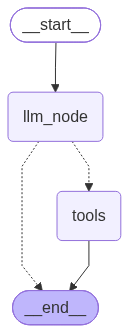

In [14]:
agent

In [15]:
agent.invoke({"messages": "Latest movie?"})

{'messages': [ToolMessage(content='Karuppu', name='search_movie_api', tool_call_id='fc_64a934b3-686a-4faa-be5c-8ec560abe1c0')]}